# Stage A Diagnostics: Checkpoint Sweep

This notebook visualizes the greedy checkpoint sweep for the frozen benchmark run `lq_seed12345_progressive` and the late-training metrics around the degradation window.

In [8]:
from pathlib import Path
import csv
import json
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

repo_root = Path.cwd().resolve()
if repo_root.name == "notebooks":
    repo_root = repo_root.parent

run_name = "dqn_n5_pgen0.4_pswap0.7_lq_seed12345_progressive"
run_dir = repo_root / "qamel" / "outputs" / "runs" / run_name
diagnostics_dir = repo_root / "qamel" / "outputs" / "studies" / "lq_seed12345_progressive" / "diagnostics"
checkpoint_dir = diagnostics_dir / "checkpoint_sweep_greedy"
figures_dir = diagnostics_dir / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

checkpoint_csv = checkpoint_dir / "checkpoint_sweep_summary.csv"
epsilon_csv = diagnostics_dir / "epsilon_sweep" / "epsilon_sweep_summary.csv"
metrics_csv = run_dir / "metrics.csv"
train_log = run_dir / "train.log"
b1_smoke_run_dir = repo_root / "qamel" / "outputs" / "runs" / "dqn_n5_pgen0.4_pswap0.7_b1_smoke_track"
best_eval_metrics_path = b1_smoke_run_dir / "checkpoints" / "best_eval_metrics.json"
b1_smoke_log_path = b1_smoke_run_dir / "train.log"

print("repo_root:", repo_root)
print("checkpoint_csv:", checkpoint_csv)
print("epsilon_csv:", epsilon_csv)
print("metrics_csv:", metrics_csv)
print("train_log:", train_log)
print("best_eval_metrics_path:", best_eval_metrics_path)
print("b1_smoke_log_path:", b1_smoke_log_path)
print("figures_dir:", figures_dir)

repo_root: /Users/idilgozel/Timing-Multiuser-Protocols
checkpoint_csv: /Users/idilgozel/Timing-Multiuser-Protocols/qamel/outputs/studies/lq_seed12345_progressive/diagnostics/checkpoint_sweep_greedy/checkpoint_sweep_summary.csv
epsilon_csv: /Users/idilgozel/Timing-Multiuser-Protocols/qamel/outputs/studies/lq_seed12345_progressive/diagnostics/epsilon_sweep/epsilon_sweep_summary.csv
metrics_csv: /Users/idilgozel/Timing-Multiuser-Protocols/qamel/outputs/runs/dqn_n5_pgen0.4_pswap0.7_lq_seed12345_progressive/metrics.csv
train_log: /Users/idilgozel/Timing-Multiuser-Protocols/qamel/outputs/runs/dqn_n5_pgen0.4_pswap0.7_lq_seed12345_progressive/train.log
figures_dir: /Users/idilgozel/Timing-Multiuser-Protocols/qamel/outputs/studies/lq_seed12345_progressive/diagnostics/figures


In [9]:
with checkpoint_csv.open(newline="", encoding="utf-8") as f:
    checkpoint_rows = list(csv.DictReader(f))

for row in checkpoint_rows:
    for key in row:
        row[key] = float(row[key])


with epsilon_csv.open(newline="", encoding="utf-8") as f:
    epsilon_rows = list(csv.DictReader(f))

for row in epsilon_rows:
    for key in row:
        row[key] = float(row[key])

with metrics_csv.open(newline="", encoding="utf-8") as f:
    metric_rows = list(csv.DictReader(f))

for row in metric_rows:
    for key in [
        "episode",
        "global_step",
        "epsilon",
        "avg_return_window",
        "success_proxy_window",
        "avg_steps_window",
        "avg_ready_nodes_window",
        "checkpoint_saved",
    ]:
        row[key] = float(row[key])
    loss = row.get("avg_loss_window", "")
    row["avg_loss_window"] = float(loss) if loss else float("nan")

checkpoint_rows[:2], epsilon_rows[:3], metric_rows[-3:]

([{'checkpoint_episode': 500.0,
   'success_rate': 0.21,
   'timeout_rate': 0.79,
   'mean_return': -121.11023295005648,
   'mean_steps': 81.344,
   'mean_ent_attempt_max': 11.082,
   'mean_swap_attempt_max': 1.046},
  {'checkpoint_episode': 550.0,
   'success_rate': 0.0,
   'timeout_rate': 1.0,
   'mean_return': -199.0,
   'mean_steps': 100.0,
   'mean_ent_attempt_max': 0.0,
   'mean_swap_attempt_max': 0.0}],
 [{'checkpoint_episode': 500.0,
   'eval_epsilon': 0.0,
   'success_rate': 0.21,
   'timeout_rate': 0.79,
   'mean_return': -121.11023295005648,
   'mean_steps': 81.344,
   'mean_ent_attempt_max': 11.082,
   'mean_swap_attempt_max': 1.046},
  {'checkpoint_episode': 500.0,
   'eval_epsilon': 0.02,
   'success_rate': 0.338,
   'timeout_rate': 0.662,
   'mean_return': -92.36645429427043,
   'mean_steps': 76.956,
   'mean_ent_attempt_max': 21.332,
   'mean_swap_attempt_max': 1.922},
  {'checkpoint_episode': 500.0,
   'eval_epsilon': 0.05,
   'success_rate': 0.42,
   'timeout_rate': 0

## Checkpoint Sweep Summary

In [10]:
checkpoint_rows

[{'checkpoint_episode': 500.0,
  'success_rate': 0.21,
  'timeout_rate': 0.79,
  'mean_return': -121.11023295005648,
  'mean_steps': 81.344,
  'mean_ent_attempt_max': 11.082,
  'mean_swap_attempt_max': 1.046},
 {'checkpoint_episode': 550.0,
  'success_rate': 0.0,
  'timeout_rate': 1.0,
  'mean_return': -199.0,
  'mean_steps': 100.0,
  'mean_ent_attempt_max': 0.0,
  'mean_swap_attempt_max': 0.0},
 {'checkpoint_episode': 600.0,
  'success_rate': 0.0,
  'timeout_rate': 1.0,
  'mean_return': -199.0,
  'mean_steps': 100.0,
  'mean_ent_attempt_max': 10.194,
  'mean_swap_attempt_max': 0.226},
 {'checkpoint_episode': 650.0,
  'success_rate': 0.038,
  'timeout_rate': 0.962,
  'mean_return': -189.06746260932502,
  'mean_steps': 97.072,
  'mean_ent_attempt_max': 23.886,
  'mean_swap_attempt_max': 1.982},
 {'checkpoint_episode': 700.0,
  'success_rate': 0.186,
  'timeout_rate': 0.814,
  'mean_return': -142.97964833843028,
  'mean_steps': 84.432,
  'mean_ent_attempt_max': 37.962,
  'mean_swap_attem

saved: /Users/idilgozel/Timing-Multiuser-Protocols/qamel/outputs/studies/lq_seed12345_progressive/diagnostics/figures/checkpoint_sweep_overview.png


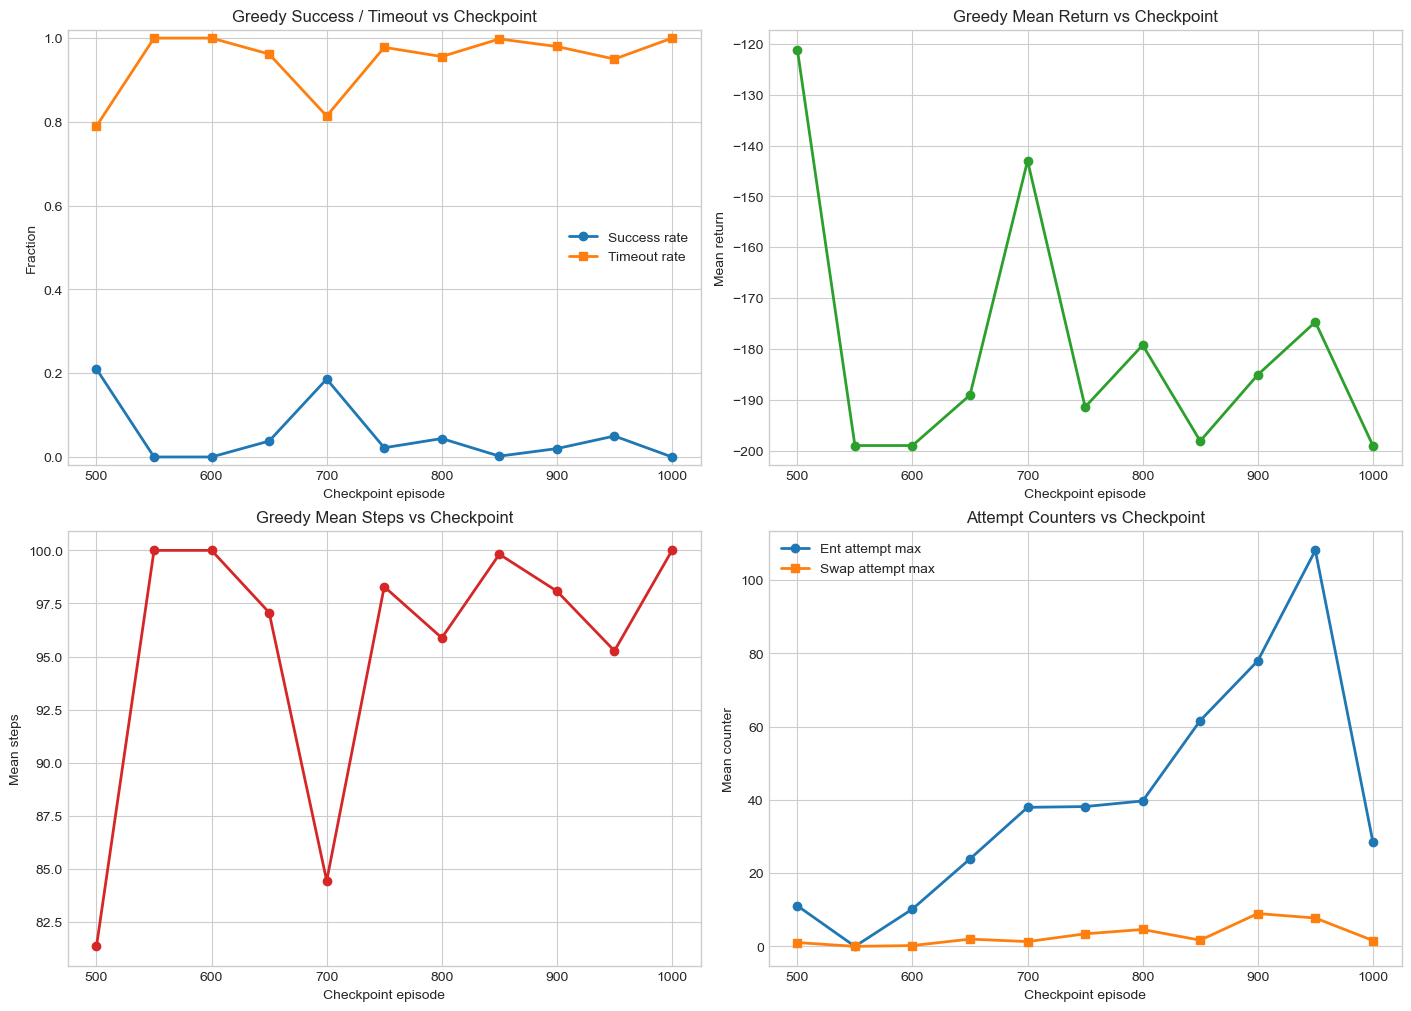

In [11]:
episodes = [row["checkpoint_episode"] for row in checkpoint_rows]
success = [row["success_rate"] for row in checkpoint_rows]
timeout = [row["timeout_rate"] for row in checkpoint_rows]
returns = [row["mean_return"] for row in checkpoint_rows]
steps = [row["mean_steps"] for row in checkpoint_rows]
ent_counts = [row["mean_ent_attempt_max"] for row in checkpoint_rows]
swap_counts = [row["mean_swap_attempt_max"] for row in checkpoint_rows]

fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)

axes[0, 0].plot(episodes, success, marker="o", linewidth=2, label="Success rate")
axes[0, 0].plot(episodes, timeout, marker="s", linewidth=2, label="Timeout rate")
axes[0, 0].set_title("Greedy Success / Timeout vs Checkpoint")
axes[0, 0].set_xlabel("Checkpoint episode")
axes[0, 0].set_ylabel("Fraction")
axes[0, 0].set_ylim(-0.02, 1.02)
axes[0, 0].legend()

axes[0, 1].plot(episodes, returns, marker="o", linewidth=2, color="tab:green")
axes[0, 1].set_title("Greedy Mean Return vs Checkpoint")
axes[0, 1].set_xlabel("Checkpoint episode")
axes[0, 1].set_ylabel("Mean return")

axes[1, 0].plot(episodes, steps, marker="o", linewidth=2, color="tab:red")
axes[1, 0].set_title("Greedy Mean Steps vs Checkpoint")
axes[1, 0].set_xlabel("Checkpoint episode")
axes[1, 0].set_ylabel("Mean steps")

axes[1, 1].plot(episodes, ent_counts, marker="o", linewidth=2, label="Ent attempt max")
axes[1, 1].plot(episodes, swap_counts, marker="s", linewidth=2, label="Swap attempt max")
axes[1, 1].set_title("Attempt Counters vs Checkpoint")
axes[1, 1].set_xlabel("Checkpoint episode")
axes[1, 1].set_ylabel("Mean counter")
axes[1, 1].legend()

out_path = figures_dir / "checkpoint_sweep_overview.png"
fig.savefig(out_path, dpi=160, bbox_inches="tight")
print("saved:", out_path)
plt.show()

## Late-Training Metrics

saved: /Users/idilgozel/Timing-Multiuser-Protocols/qamel/outputs/studies/lq_seed12345_progressive/diagnostics/figures/late_training_metrics.png


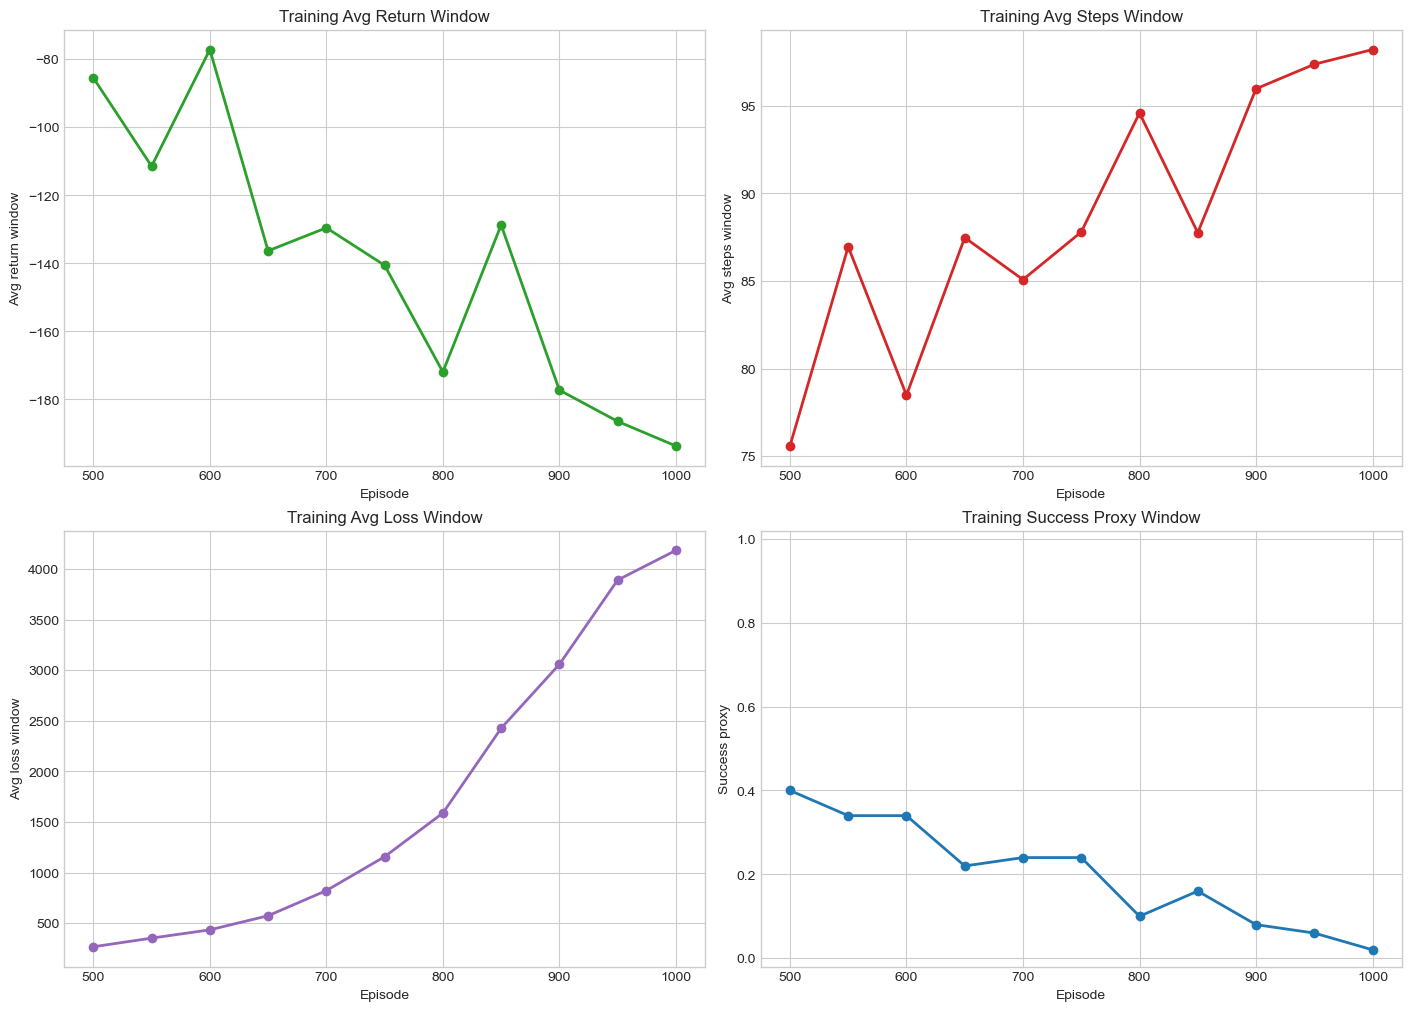

In [12]:
metric_episodes = [row["episode"] for row in metric_rows if row["episode"] >= 500]
avg_return = [row["avg_return_window"] for row in metric_rows if row["episode"] >= 500]
avg_steps = [row["avg_steps_window"] for row in metric_rows if row["episode"] >= 500]
avg_loss = [row["avg_loss_window"] for row in metric_rows if row["episode"] >= 500]
success_proxy = [row["success_proxy_window"] for row in metric_rows if row["episode"] >= 500]

fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)

axes[0, 0].plot(metric_episodes, avg_return, marker="o", linewidth=2, color="tab:green")
axes[0, 0].set_title("Training Avg Return Window")
axes[0, 0].set_xlabel("Episode")
axes[0, 0].set_ylabel("Avg return window")

axes[0, 1].plot(metric_episodes, avg_steps, marker="o", linewidth=2, color="tab:red")
axes[0, 1].set_title("Training Avg Steps Window")
axes[0, 1].set_xlabel("Episode")
axes[0, 1].set_ylabel("Avg steps window")

axes[1, 0].plot(metric_episodes, avg_loss, marker="o", linewidth=2, color="tab:purple")
axes[1, 0].set_title("Training Avg Loss Window")
axes[1, 0].set_xlabel("Episode")
axes[1, 0].set_ylabel("Avg loss window")

axes[1, 1].plot(metric_episodes, success_proxy, marker="o", linewidth=2, color="tab:blue")
axes[1, 1].set_title("Training Success Proxy Window")
axes[1, 1].set_xlabel("Episode")
axes[1, 1].set_ylabel("Success proxy")
axes[1, 1].set_ylim(-0.02, 1.02)

out_path = figures_dir / "late_training_metrics.png"
fig.savefig(out_path, dpi=160, bbox_inches="tight")
print("saved:", out_path)
plt.show()

## A2 Epsilon Sweep

This section records the greedy-vs-tiny-epsilon evaluation for checkpoints `500`, `700`, and `1000` using the frozen benchmark settings.

In [13]:
epsilon_rows

[{'checkpoint_episode': 500.0,
  'eval_epsilon': 0.0,
  'success_rate': 0.21,
  'timeout_rate': 0.79,
  'mean_return': -121.11023295005648,
  'mean_steps': 81.344,
  'mean_ent_attempt_max': 11.082,
  'mean_swap_attempt_max': 1.046},
 {'checkpoint_episode': 500.0,
  'eval_epsilon': 0.02,
  'success_rate': 0.338,
  'timeout_rate': 0.662,
  'mean_return': -92.36645429427043,
  'mean_steps': 76.956,
  'mean_ent_attempt_max': 21.332,
  'mean_swap_attempt_max': 1.922},
 {'checkpoint_episode': 500.0,
  'eval_epsilon': 0.05,
  'success_rate': 0.42,
  'timeout_rate': 0.58,
  'mean_return': -72.82425337369865,
  'mean_steps': 72.236,
  'mean_ent_attempt_max': 31.448,
  'mean_swap_attempt_max': 2.712},
 {'checkpoint_episode': 700.0,
  'eval_epsilon': 0.0,
  'success_rate': 0.186,
  'timeout_rate': 0.814,
  'mean_return': -142.97964833843028,
  'mean_steps': 84.432,
  'mean_ent_attempt_max': 37.962,
  'mean_swap_attempt_max': 1.308},
 {'checkpoint_episode': 700.0,
  'eval_epsilon': 0.02,
  'succes

saved: /Users/idilgozel/Timing-Multiuser-Protocols/qamel/outputs/studies/lq_seed12345_progressive/diagnostics/figures/epsilon_sweep_comparison.png


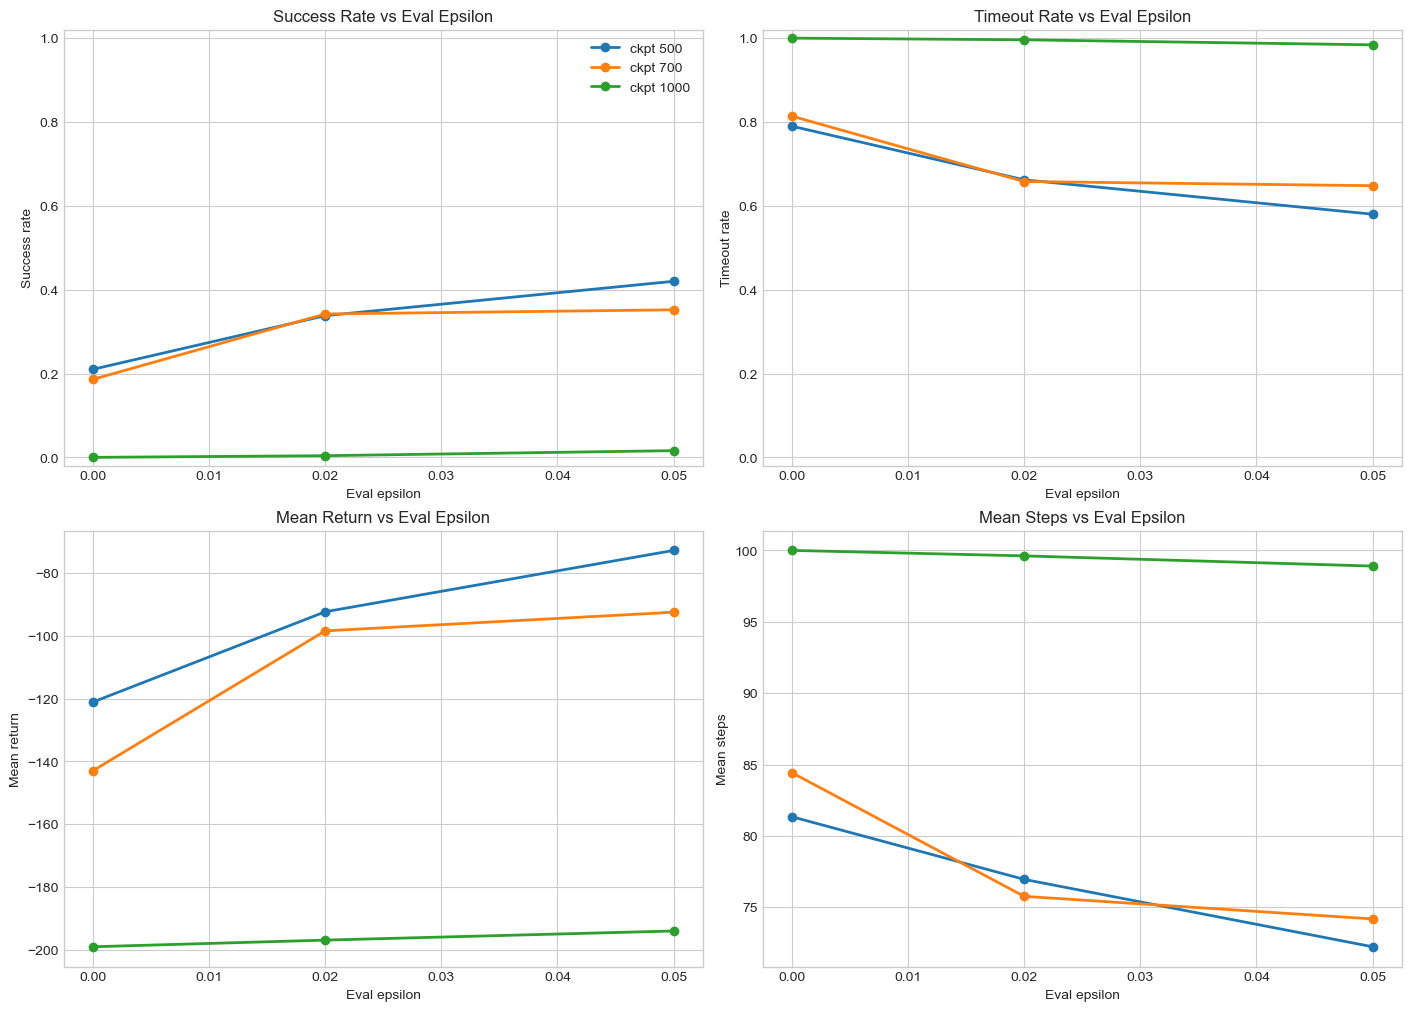

In [14]:
epsilons = sorted({row["eval_epsilon"] for row in epsilon_rows})
checkpoint_eps = sorted({row["checkpoint_episode"] for row in epsilon_rows})

def series(metric_name, checkpoint_episode):
    subset = [row for row in epsilon_rows if row["checkpoint_episode"] == checkpoint_episode]
    subset = sorted(subset, key=lambda row: row["eval_epsilon"])
    return [row[metric_name] for row in subset]

fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)

for checkpoint_episode in checkpoint_eps:
    label = f"ckpt {int(checkpoint_episode)}"
    axes[0, 0].plot(epsilons, series("success_rate", checkpoint_episode), marker="o", linewidth=2, label=label)
    axes[0, 1].plot(epsilons, series("timeout_rate", checkpoint_episode), marker="o", linewidth=2, label=label)
    axes[1, 0].plot(epsilons, series("mean_return", checkpoint_episode), marker="o", linewidth=2, label=label)
    axes[1, 1].plot(epsilons, series("mean_steps", checkpoint_episode), marker="o", linewidth=2, label=label)

axes[0, 0].set_title("Success Rate vs Eval Epsilon")
axes[0, 0].set_xlabel("Eval epsilon")
axes[0, 0].set_ylabel("Success rate")
axes[0, 0].set_ylim(-0.02, 1.02)
axes[0, 0].legend()

axes[0, 1].set_title("Timeout Rate vs Eval Epsilon")
axes[0, 1].set_xlabel("Eval epsilon")
axes[0, 1].set_ylabel("Timeout rate")
axes[0, 1].set_ylim(-0.02, 1.02)

axes[1, 0].set_title("Mean Return vs Eval Epsilon")
axes[1, 0].set_xlabel("Eval epsilon")
axes[1, 0].set_ylabel("Mean return")

axes[1, 1].set_title("Mean Steps vs Eval Epsilon")
axes[1, 1].set_xlabel("Eval epsilon")
axes[1, 1].set_ylabel("Mean steps")

out_path = figures_dir / "epsilon_sweep_comparison.png"
fig.savefig(out_path, dpi=160, bbox_inches="tight")
print("saved:", out_path)
plt.show()

## B1 Best-Checkpoint Tracking

This section records the small Stage B1 mechanism added to training. The goal is to keep the existing `latest.pt` behavior while also tracking a `best_eval.pt` checkpoint selected by evaluation metrics.

Selection rule used in code:

1. higher greedy success rate
2. if tied, higher mean return
3. if still tied, lower mean steps

The smoke test used a short run (`b1_smoke_track`) with `best_eval_every=1` so that best-checkpoint updates could be observed quickly.

In [ ]:
with best_eval_metrics_path.open(encoding="utf-8") as f:
    best_eval_metrics = json.load(f)

best_eval_metrics

In [ ]:
log_lines = b1_smoke_log_path.read_text(encoding="utf-8").splitlines()
key_lines = [line for line in log_lines if "Best-eval check" in line or "New best-eval checkpoint" in line or "Loaded DQN checkpoint" in line or "Resuming from checkpoint" in line]
key_lines

## Notes

- The best late checkpoint from the greedy sweep is expected to be `500`.
- The training-side metrics should show whether the later collapse coincides with rising loss and worsening return/step trends.
- Running this notebook saves the figures into `qamel/outputs/studies/lq_seed12345_progressive/diagnostics/figures/`.
- The A2 epsilon sweep shows whether small evaluation noise recovers useful behavior from brittle checkpoints.
- Running this notebook also saves `epsilon_sweep_comparison.png` into the diagnostics figures directory.
- Stage B1 adds `checkpoints/best_eval.pt` and `checkpoints/best_eval_metrics.json` as optional model-selection artifacts, without changing the default latest-checkpoint behavior.


# Myriad Python environment note


```bash
cd ~/Timing-Multiuser-Protocols

module unload compilers mpi gcc-libs
module load gcc-libs/10.2.0
module load python3/3.9-gnu-10.2.0
module load pytorch/2.1.0/gpu

python -m venv --system-site-packages ~/venvs/timing-multiuser
source ~/venvs/timing-multiuser/bin/activate
pip install --upgrade pip
pip install rich scipy matplotlib networkx seaborn notebook


# Name of env
~/venvs/timing-multiuser

eval command:

python scripts/evaluate_qamel.py \
  --n 5 --pgen 0.4 --pswap 0.7 \
  --eval_episodes 500 --model_tag fixed_reward_best_eval \
  --obs_mode counter_exposed_plus_ready --seed 42 \
  --model_path qamel/outputs/runs/dqn_n5_pgen0.4_pswap0.7_fixed_reward/checkpoints/best_eval.pt \
  --prefer_swap_when_ready
